<a href="https://colab.research.google.com/github/gar-nov/tirocinio/blob/main/DS_MEDIUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/VEREMI_ATTACKS"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))


['Quietanza di Pagamento_I_Rata_388749211.pdf', 'Foto.pdf', 'heap2_mio.gdoc', 'IMG_7772.jpeg', 'EC1EDA6B-75A2-4B52-9F0B-E392E815FE17.jpeg', '516D3AAF-859C-45AE-8C31-71BBC30ED370.jpeg', 'image (5).jpg', 'image (4).jpg', '0332D4D2-A7B6-4956-A9D5-6C10F4666DE0.jpeg', 'image (3).jpg', 'Acme Store.pdf', 'image (2).jpg', 'image (1).jpg', 'image.jpg', 'Colab Notebooks', 'T', 'dataset_veremi', 'Classroom', 'Copia di Log 2024 CS.gsheet', 'Copia di Log 2025 CS.gsheet', 'veremi_clean.csv', 'veremi_selected.csv']


In [ ]:
print(os.listdir("/content/drive/MyDrive/VEREMI_ATTACKS"))


['veins_maat.uc1.14505224.180205_165538.tar', 'veins_maat.uc1.14505286.180205_170242.tar', 'veins_maat.uc1.14505440.180205_172032.tar', 'veins_maat.uc1.14505681.180205_181326.tar', 'veins_maat.uc1.14505982.180205_194910.tar']


In [ ]:
base_path = "/content/drive/MyDrive/VEREMI_ATTACKS"


In [ ]:
import tarfile
import json
import pandas as pd
import os

base_path = "/content/drive/MyDrive/VEREMI_ATTACKS"

all_rows = []

for fname in os.listdir(base_path):
    if fname.endswith(".tar"):
        tar_path = os.path.join(base_path, fname)
        print("Estrazione:", fname)

        with tarfile.open(tar_path, "r") as tar:

            # 1) Leggo la Ground Truth
            gt_entries = []
            for member in tar.getmembers():
                if "GroundTruthJSONlog.json" in member.name:
                    f = tar.extractfile(member)
                    for line in f:
                        line = line.decode("utf-8").strip()
                        if line:
                            gt_entries.append(json.loads(line))
                    break

            # Mapping sender → attacker (0 benign, 1 attacker)
            label_map = {
                entry["sender"]: 1 if entry["attackerType"] > 0 else 0
                for entry in gt_entries
            }

            # 2) Leggo tutti i JSONlog
            for member in tar.getmembers():
                if "JSONlog-" in member.name:
                    f = tar.extractfile(member)
                    for line in f:
                        line = line.decode("utf-8").strip()
                        if not line:
                            continue

                        msg = json.loads(line)

                        # 🔥 Considero SOLO type == 3 (contiene sender)
                        if msg.get("type") != 3:
                            continue

                        sender = msg["sender"]
                        msg["attack"] = label_map.get(sender, 0)
                        msg["source_file"] = fname
                        all_rows.append(msg)

df = pd.DataFrame(all_rows)
print("Shape finale:", df.shape)
df.head()



Estrazione: veins_maat.uc1.14505224.180205_165538.tar
Estrazione: veins_maat.uc1.14505286.180205_170242.tar
Estrazione: veins_maat.uc1.14505440.180205_172032.tar
Estrazione: veins_maat.uc1.14505681.180205_181326.tar
Estrazione: veins_maat.uc1.14505982.180205_194910.tar
Shape finale: (99411, 12)


,type,rcvTime,sendTime,sender,messageID,pos,pos_noise,spd,spd_noise,RSSI,attack,source_file
0,3,18058.207694,18058.207584,337,152434,"[3588.7998799192583, 5911.88707810359, 1.895]","[0.0, 0.0, 0.0]","[1.263214849223396, 29.669518311458273, 0.0]","[0.0, 0.0, 0.0]",2.024550e-09,0,veins_maat.uc1.14505224.180205_165538.tar
1,3,18058.343495,18058.343377,397,152750,"[3581.0756227717256, 5816.301772618594, 1.895]","[0.0, 0.0, 0.0]","[-0.04289704559629158, 44.306048556250325, 0.0]","[0.0, 0.0, 0.0]",1.412736e-08,0,veins_maat.uc1.14505224.180205_165538.tar
2,3,18058.545886,18058.545773,361,153297,"[3587.645488836924, 5847.361928773886, 1.895]","[0.0, 0.0, 0.0]","[-0.02889666208874329, 29.78356733261963, 0.0]","[0.0, 0.0, 0.0]",3.107564e-08,0,veins_maat.uc1.14505224.180205_165538.tar
3,3,18058.648307,18058.648199,355,153664,"[3587.7652890863137, 5887.587322854685, 1.895]","[0.0, 0.0, 0.0]","[0.9150021024028178, 29.655323363045895, 0.0]","[0.0, 0.0, 0.0]",3.008505e-09,0,veins_maat.uc1.14505224.180205_165538.tar
4,3,18058.969107,18058.968988,409,154680,"[3599.0051818636457, 5717.787902440039, 1.895]","[0.0, 0.0, 0.0]","[1.645915233999213, -38.36219743574617, 0.0]","[0.0, 0.0, 0.0]",9.994369e-09,0,veins_maat.uc1.14505224.180205_165538.tar


In [ ]:
df.shape

(99411, 12)

In [ ]:
# Controllo distribuzione
df["attack"].value_counts()

,count
attack,
0,85445
1,13966


In [ ]:
df_sorted = df.sort_values(by="sender", ascending=True)
df_sorted.head(20)


,type,rcvTime,sendTime,sender,messageID,pos,pos_noise,spd,spd_noise,RSSI,attack,source_file
60565,3,18005.437694,18005.437587,7,10685,"[3605.1132042787904, 5485.375902988893, 1.895]","[0.0, 0.0, 0.0]","[-2.539106733768563, 29.86375815022501, 0.0]","[0.0, 0.0, 0.0]",1.494696e-08,0,veins_maat.uc1.14505681.180205_181326.tar
92581,3,18022.437694,18022.437587,7,63630,"[3594.2498958968167, 5992.92694385777, 1.895]","[0.0, 0.0, 0.0]","[2.222231759012115, 29.84468766507366, 0.0]","[0.0, 0.0, 0.0]",5.505376e-09,0,veins_maat.uc1.14505982.180205_194910.tar
70940,3,18010.437700,18010.437587,7,25972,"[3592.9009356722922, 5634.455497518106, 1.895]","[0.0, 0.0, 0.0]","[-2.4471672166538276, 29.87345825411307, 0.0]","[0.0, 0.0, 0.0]",2.950315e-09,0,veins_maat.uc1.14505681.180205_181326.tar
70952,3,18011.437699,18011.437587,7,29218,"[3591.315954498882, 5664.3030897874, 1.895]","[0.0, 0.0, 0.0]","[-1.2504499726628602, 29.94925594478047, 0.0]","[0.0, 0.0, 0.0]",1.117368e-08,0,veins_maat.uc1.14505681.180205_181326.tar
20551,3,18005.437705,18005.437587,7,10723,"[3605.1132042787904, 5485.375902988893, 1.895]","[0.0, 0.0, 0.0]","[-2.539106733768563, 29.86375815022501, 0.0]","[0.0, 0.0, 0.0]",1.609176e-08,0,veins_maat.uc1.14505286.180205_170242.tar
20558,3,18006.437698,18006.437587,7,13170,"[3602.6680753065853, 5515.224479653348, 1.895]","[0.0, 0.0, 0.0]","[-2.4482013930913706, 29.886082821173336, 0.0]","[0.0, 0.0, 0.0]",1.911769e-08,0,veins_maat.uc1.14505286.180205_170242.tar
20536,3,18002.437696,18002.437587,7,4302,"[3615.236160254434, 5396.220505029403, 1.895]","[0.0, 0.0, 0.0]","[-3.437884445069187, 29.788902984151846, 0.0]","[0.0, 0.0, 0.0]",2.164426e-09,0,veins_maat.uc1.14505286.180205_170242.tar
20541,3,18003.437700,18003.437587,7,6296,"[3611.8070980369644, 5425.932964349922, 1.895]","[0.0, 0.0, 0.0]","[-3.4298329884426506, 29.7191379689992, 0.0]","[0.0, 0.0, 0.0]",1.377227e-09,0,veins_maat.uc1.14505286.180205_170242.tar
54390,3,18017.437701,18017.437587,7,47483,"[3587.6490802092208, 5843.660328973252, 1.895]","[0.0, 0.0, 0.0]","[-0.029079983619372782, 29.972515424072352, 0.0]","[0.0, 0.0, 0.0]",5.652340e-09,0,veins_maat.uc1.14505440.180205_172032.tar
47377,3,18003.437697,18003.437587,7,6234,"[3611.8070980369644, 5425.932964349922, 1.895]","[0.0, 0.0, 0.0]","[-3.4298329884426506, 29.7191379689992, 0.0]","[0.0, 0.0, 0.0]",1.440756e-08,0,veins_maat.uc1.14505440.180205_172032.tar


In [ ]:
# --- Estraggo pos x,y,z ---
df["pos_x"] = df["pos"].apply(lambda v: v[0])
df["pos_y"] = df["pos"].apply(lambda v: v[1])
df["pos_z"] = df["pos"].apply(lambda v: v[2])

# --- Estraggo pos_noise x,y,z ---
df["pos_noise_x"] = df["pos_noise"].apply(lambda v: v[0])
df["pos_noise_y"] = df["pos_noise"].apply(lambda v: v[1])
df["pos_noise_z"] = df["pos_noise"].apply(lambda v: v[2])

# --- Estraggo speed x,y,z ---
df["spd_x"] = df["spd"].apply(lambda v: v[0])
df["spd_y"] = df["spd"].apply(lambda v: v[1])
df["spd_z"] = df["spd"].apply(lambda v: v[2])

# --- Estraggo speed_noise x,y,z ---
df["spd_noise_x"] = df["spd_noise"].apply(lambda v: v[0])
df["spd_noise_y"] = df["spd_noise"].apply(lambda v: v[1])
df["spd_noise_z"] = df["spd_noise"].apply(lambda v: v[2])

# Mostra il dataframe completo con TUTTE le colonne
df.head()


,type,rcvTime,sendTime,sender,messageID,pos,pos_noise,spd,spd_noise,RSSI,...,pos_z,pos_noise_x,pos_noise_y,pos_noise_z,spd_x,spd_y,spd_z,spd_noise_x,spd_noise_y,spd_noise_z
0,3,18058.207694,18058.207584,337,152434,"[3588.7998799192583, 5911.88707810359, 1.895]","[0.0, 0.0, 0.0]","[1.263214849223396, 29.669518311458273, 0.0]","[0.0, 0.0, 0.0]",2.024550e-09,...,1.895,0.0,0.0,0.0,1.263215,29.669518,0.0,0.0,0.0,0.0
1,3,18058.343495,18058.343377,397,152750,"[3581.0756227717256, 5816.301772618594, 1.895]","[0.0, 0.0, 0.0]","[-0.04289704559629158, 44.306048556250325, 0.0]","[0.0, 0.0, 0.0]",1.412736e-08,...,1.895,0.0,0.0,0.0,-0.042897,44.306049,0.0,0.0,0.0,0.0
2,3,18058.545886,18058.545773,361,153297,"[3587.645488836924, 5847.361928773886, 1.895]","[0.0, 0.0, 0.0]","[-0.02889666208874329, 29.78356733261963, 0.0]","[0.0, 0.0, 0.0]",3.107564e-08,...,1.895,0.0,0.0,0.0,-0.028897,29.783567,0.0,0.0,0.0,0.0
3,3,18058.648307,18058.648199,355,153664,"[3587.7652890863137, 5887.587322854685, 1.895]","[0.0, 0.0, 0.0]","[0.9150021024028178, 29.655323363045895, 0.0]","[0.0, 0.0, 0.0]",3.008505e-09,...,1.895,0.0,0.0,0.0,0.915002,29.655323,0.0,0.0,0.0,0.0
4,3,18058.969107,18058.968988,409,154680,"[3599.0051818636457, 5717.787902440039, 1.895]","[0.0, 0.0, 0.0]","[1.645915233999213, -38.36219743574617, 0.0]","[0.0, 0.0, 0.0]",9.994369e-09,...,1.895,0.0,0.0,0.0,1.645915,-38.362197,0.0,0.0,0.0,0.0


In [ ]:
# --- Cancello le colonne originali ---
df = df.drop(columns=["source_file"])

# Mostro il dataframe completo pulito
df.head()

,type,rcvTime,sendTime,sender,messageID,RSSI,attack,pos_x,pos_y,pos_z,pos_noise_x,pos_noise_y,pos_noise_z,spd_x,spd_y,spd_z,spd_noise_x,spd_noise_y,spd_noise_z
0,3,18058.207694,18058.207584,337,152434,2.024550e-09,0,3588.799880,5911.887078,1.895,0.0,0.0,0.0,1.263215,29.669518,0.0,0.0,0.0,0.0
1,3,18058.343495,18058.343377,397,152750,1.412736e-08,0,3581.075623,5816.301773,1.895,0.0,0.0,0.0,-0.042897,44.306049,0.0,0.0,0.0,0.0
2,3,18058.545886,18058.545773,361,153297,3.107564e-08,0,3587.645489,5847.361929,1.895,0.0,0.0,0.0,-0.028897,29.783567,0.0,0.0,0.0,0.0
3,3,18058.648307,18058.648199,355,153664,3.008505e-09,0,3587.765289,5887.587323,1.895,0.0,0.0,0.0,0.915002,29.655323,0.0,0.0,0.0,0.0
4,3,18058.969107,18058.968988,409,154680,9.994369e-09,0,3599.005182,5717.787902,1.895,0.0,0.0,0.0,1.645915,-38.362197,0.0,0.0,0.0,0.0


In [ ]:
df.duplicated().sum()


np.int64(17575)

In [ ]:
df_clean = df.drop_duplicates()


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean.shape

(81836, 19)

In [ ]:
# Controllo distribuzione
df_clean["attack"].value_counts()

,count
attack,
0,67870
1,13966


<Figure size 1600x1200 with 0 Axes>

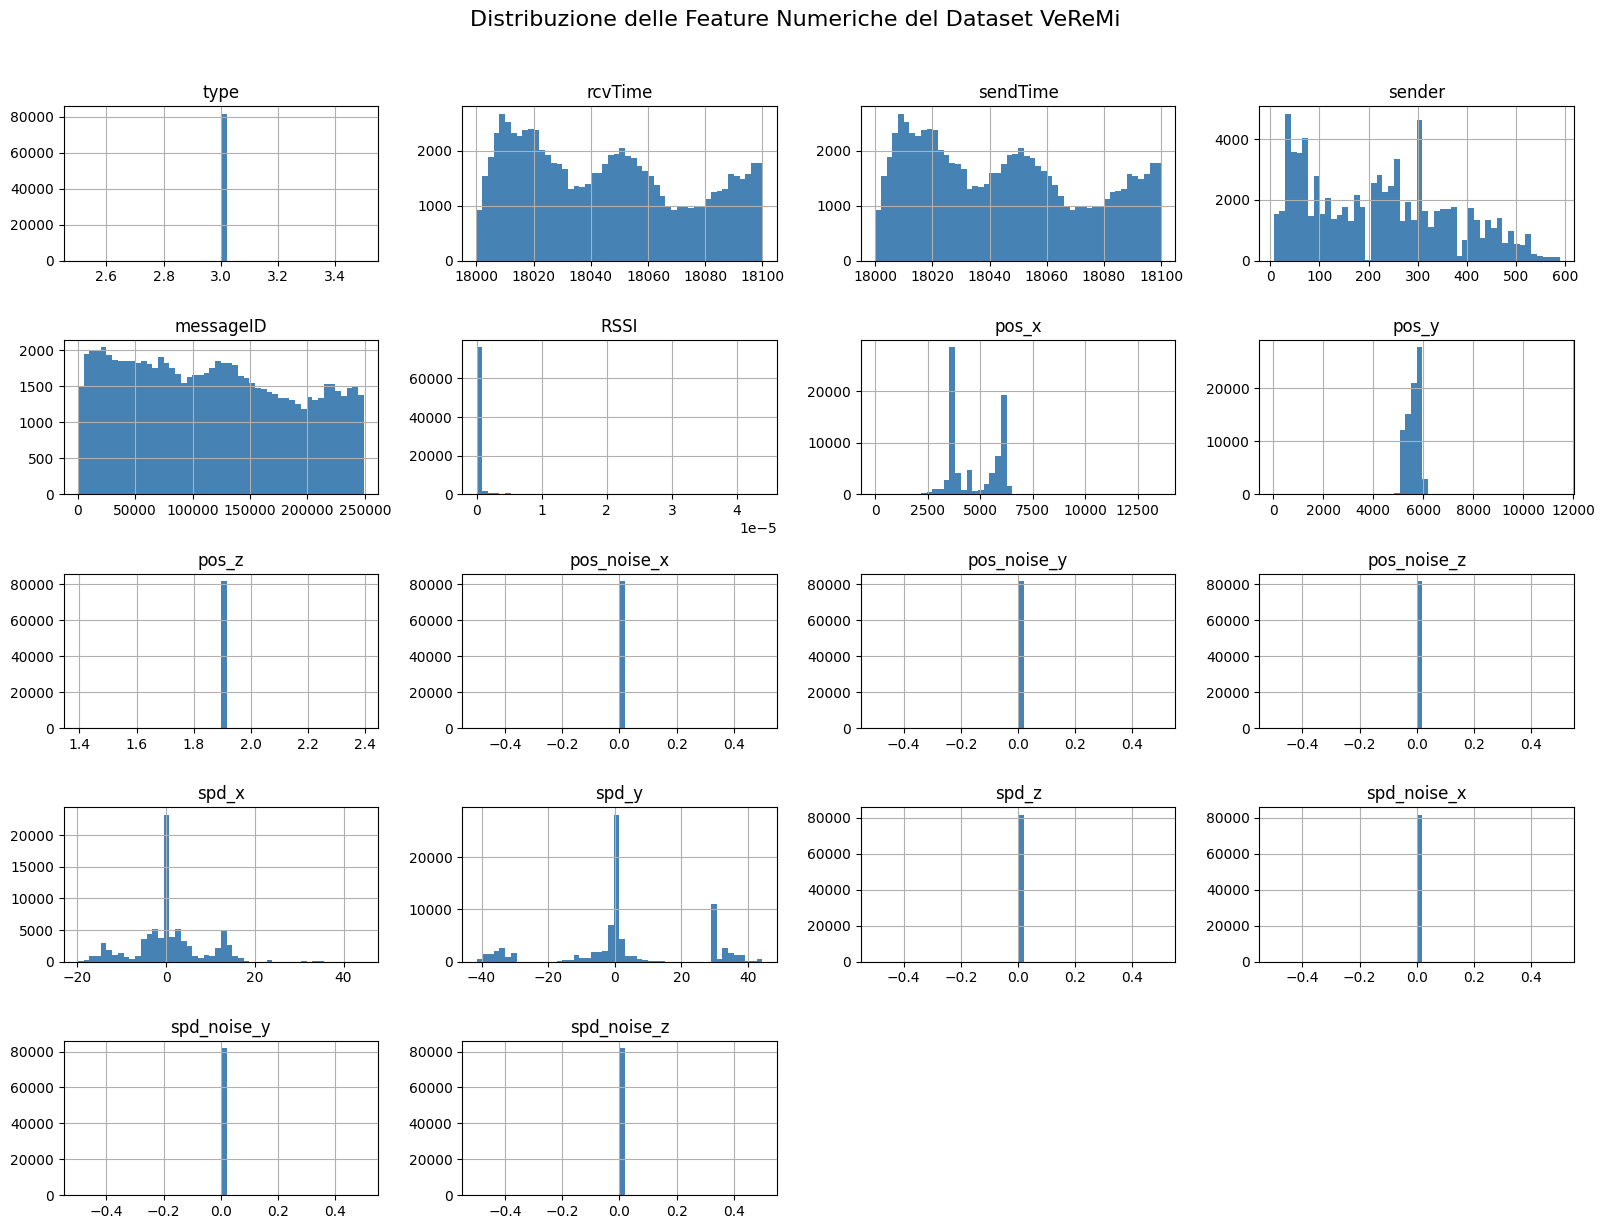

In [ ]:
import matplotlib.pyplot as plt

# Se vuoi escludere anche 'attack' dagli istogrammi:
df_num = df_clean.drop(columns=["attack"])

plt.figure(figsize=(16, 12))
df_num.hist(bins=50, figsize=(16, 12), color="steelblue")
plt.suptitle("Distribuzione delle Feature Numeriche del Dataset VeReMi", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()





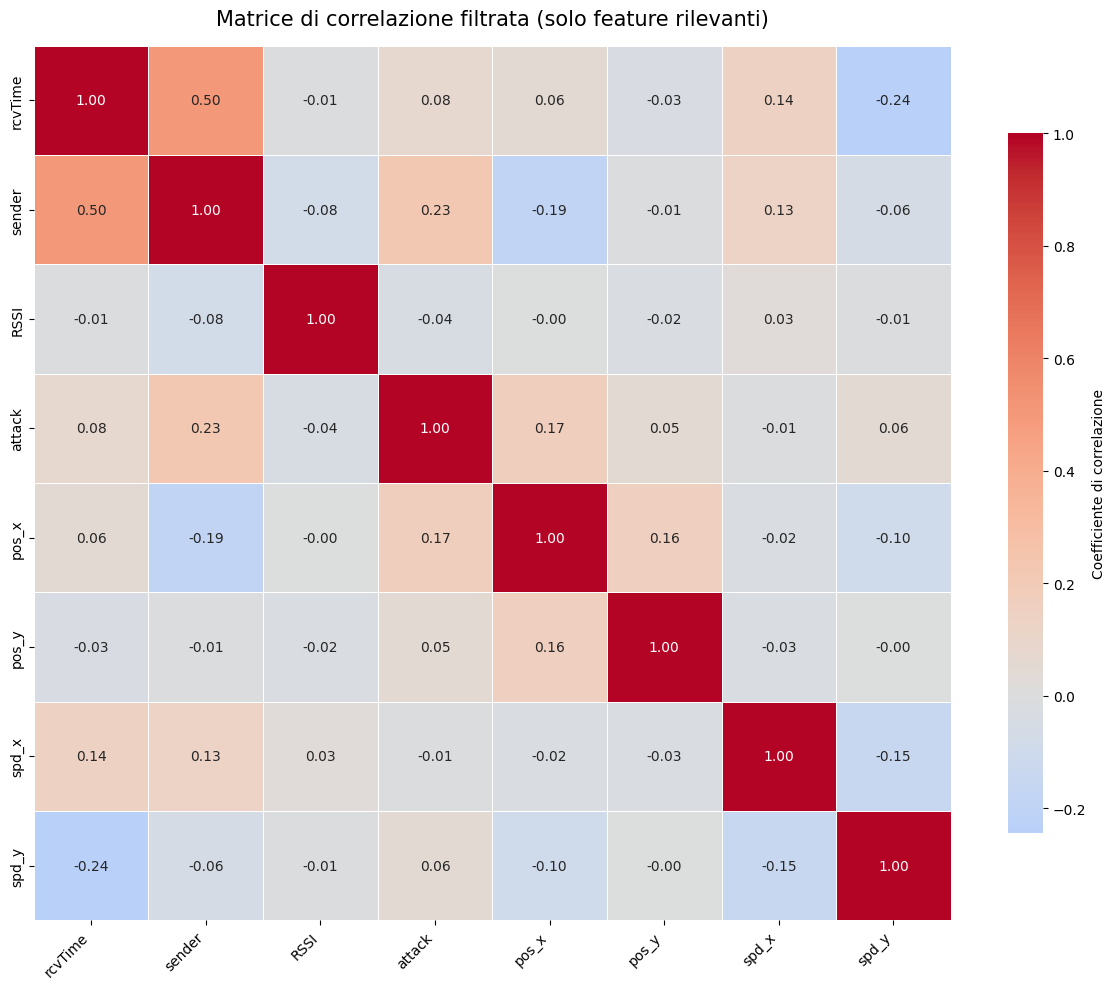

In [ ]:
cols_to_drop = [
    "type",
    "pos_z",
    "spd_z",
    "pos_noise_x", "pos_noise_y", "pos_noise_z",
    "spd_noise_x", "spd_noise_y", "spd_noise_z",
    "sendTime",
    "messageID"
]

df_corr = df_clean.drop(columns=cols_to_drop)

# Calcolo matrice di correlazione solo sulle feature utili
df_num = df_corr.select_dtypes(include=['float64', 'int64'])
corr_matrix = df_num.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Coefficiente di correlazione"}
)

plt.title("Matrice di correlazione filtrata (solo feature rilevanti)", fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2748288101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-2748288101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-2748288101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-2748288101.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipython-input-2748288101.py:15: FutureWarning: 

Passin

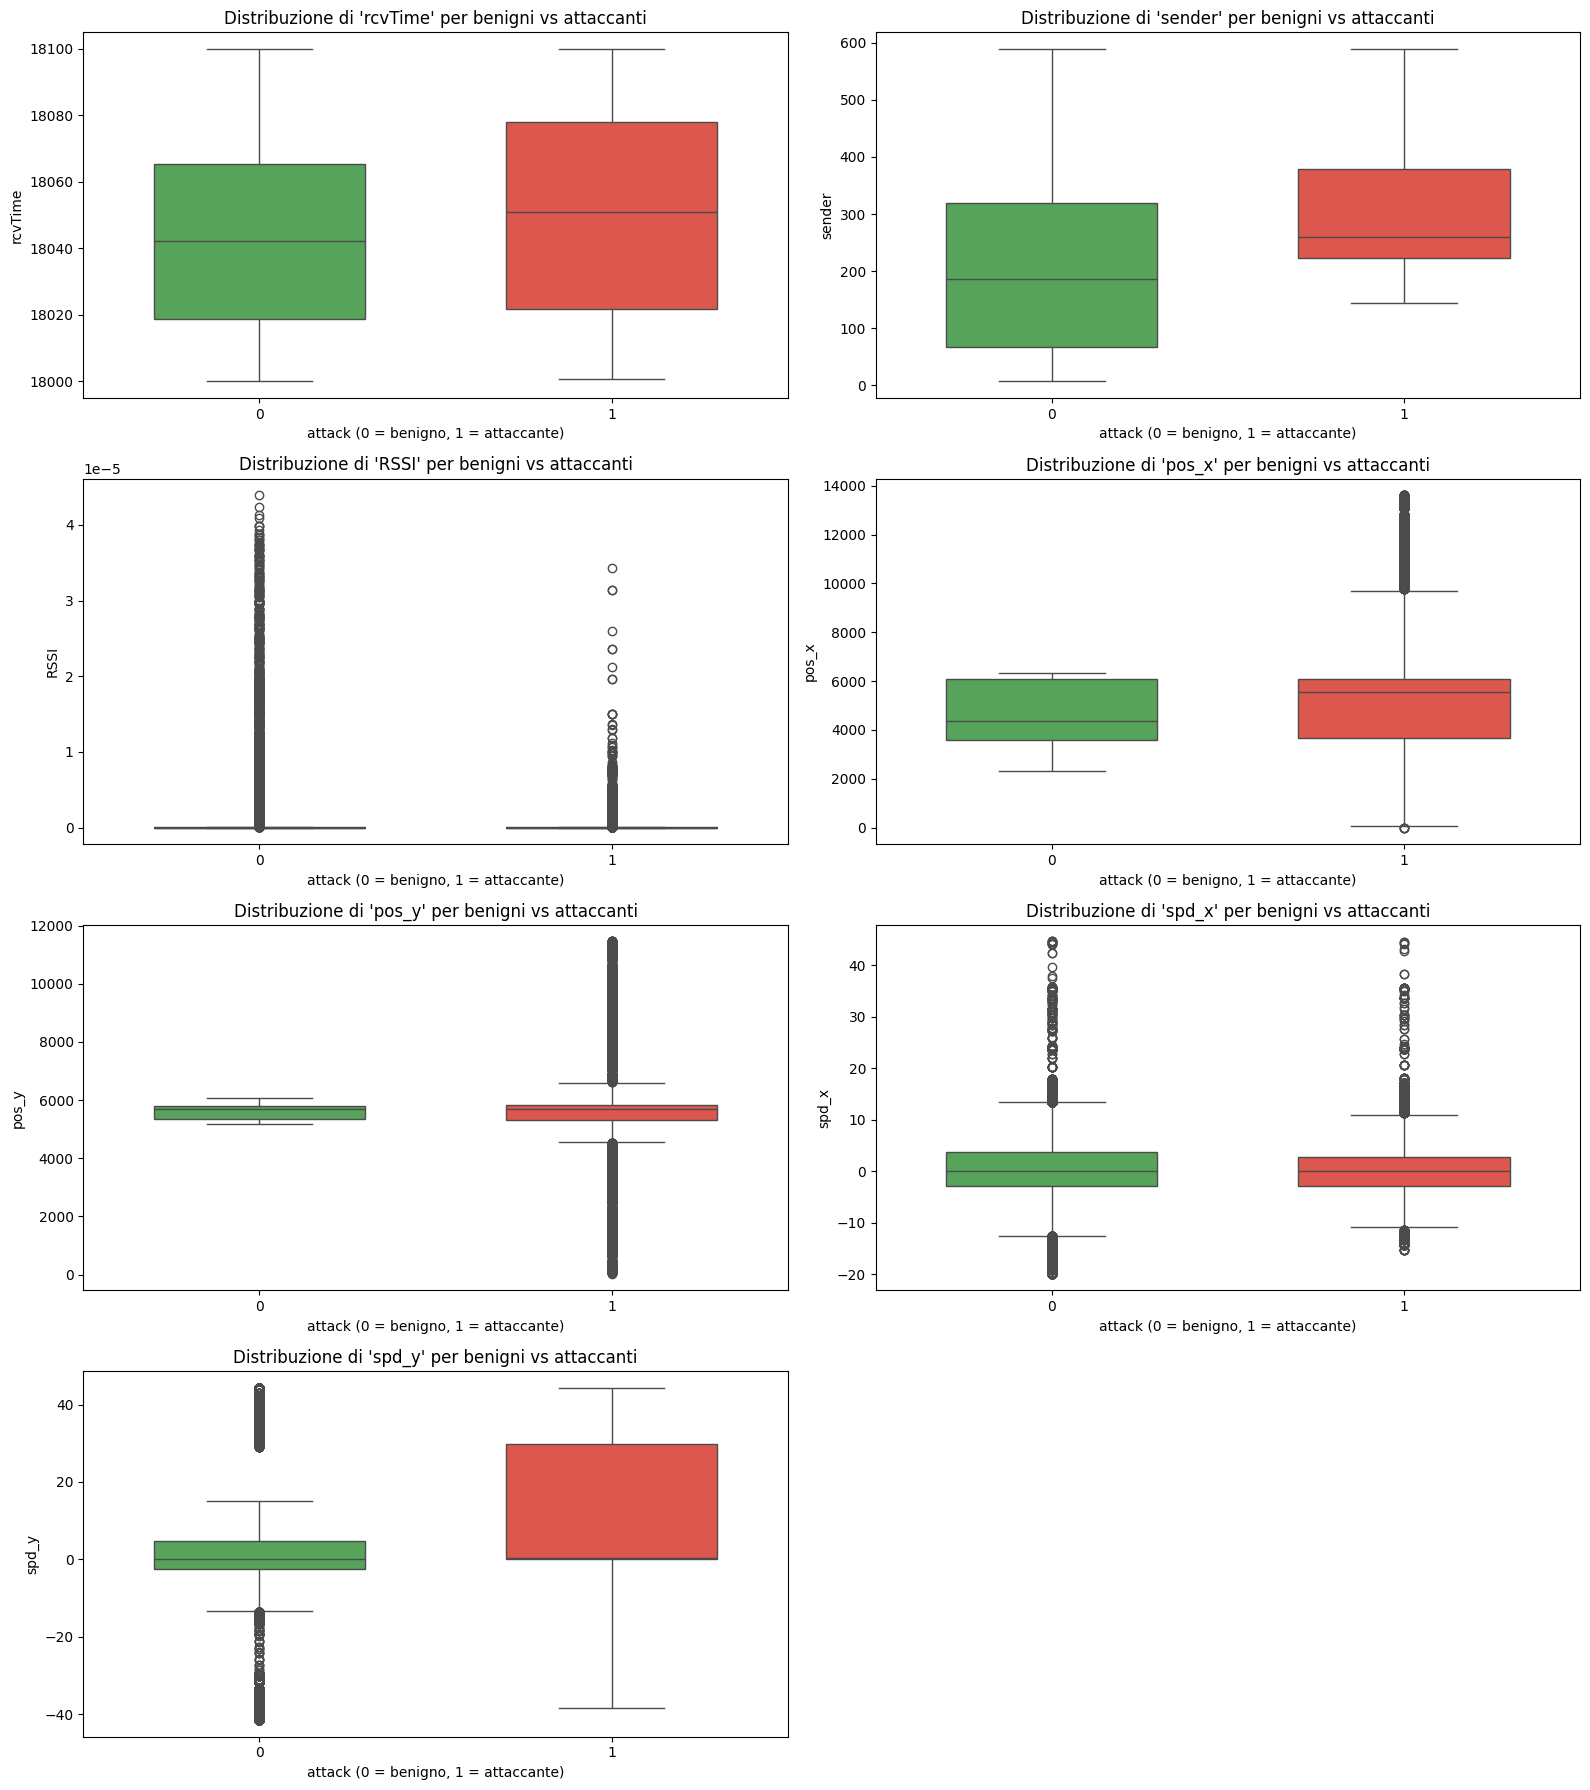

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleziono solo le feature numeriche (escluse label e colonne inutili)
cols_for_boxplot = [
    "rcvTime", "sender", "RSSI",
    "pos_x", "pos_y",
    "spd_x", "spd_y"
]

plt.figure(figsize=(16, 18))

for i, col in enumerate(cols_for_boxplot, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(
        data=df_clean,
        x="attack",
        y=col,
        palette=["#4CAF50", "#F44336"],   # verde vs rosso (benigno vs attacco)
        width=0.6
    )
    plt.title(f"Distribuzione di '{col}' per benigni vs attaccanti", fontsize=12)
    plt.xlabel("attack (0 = benigno, 1 = attaccante)")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


/tmp/ipython-input-754846228.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


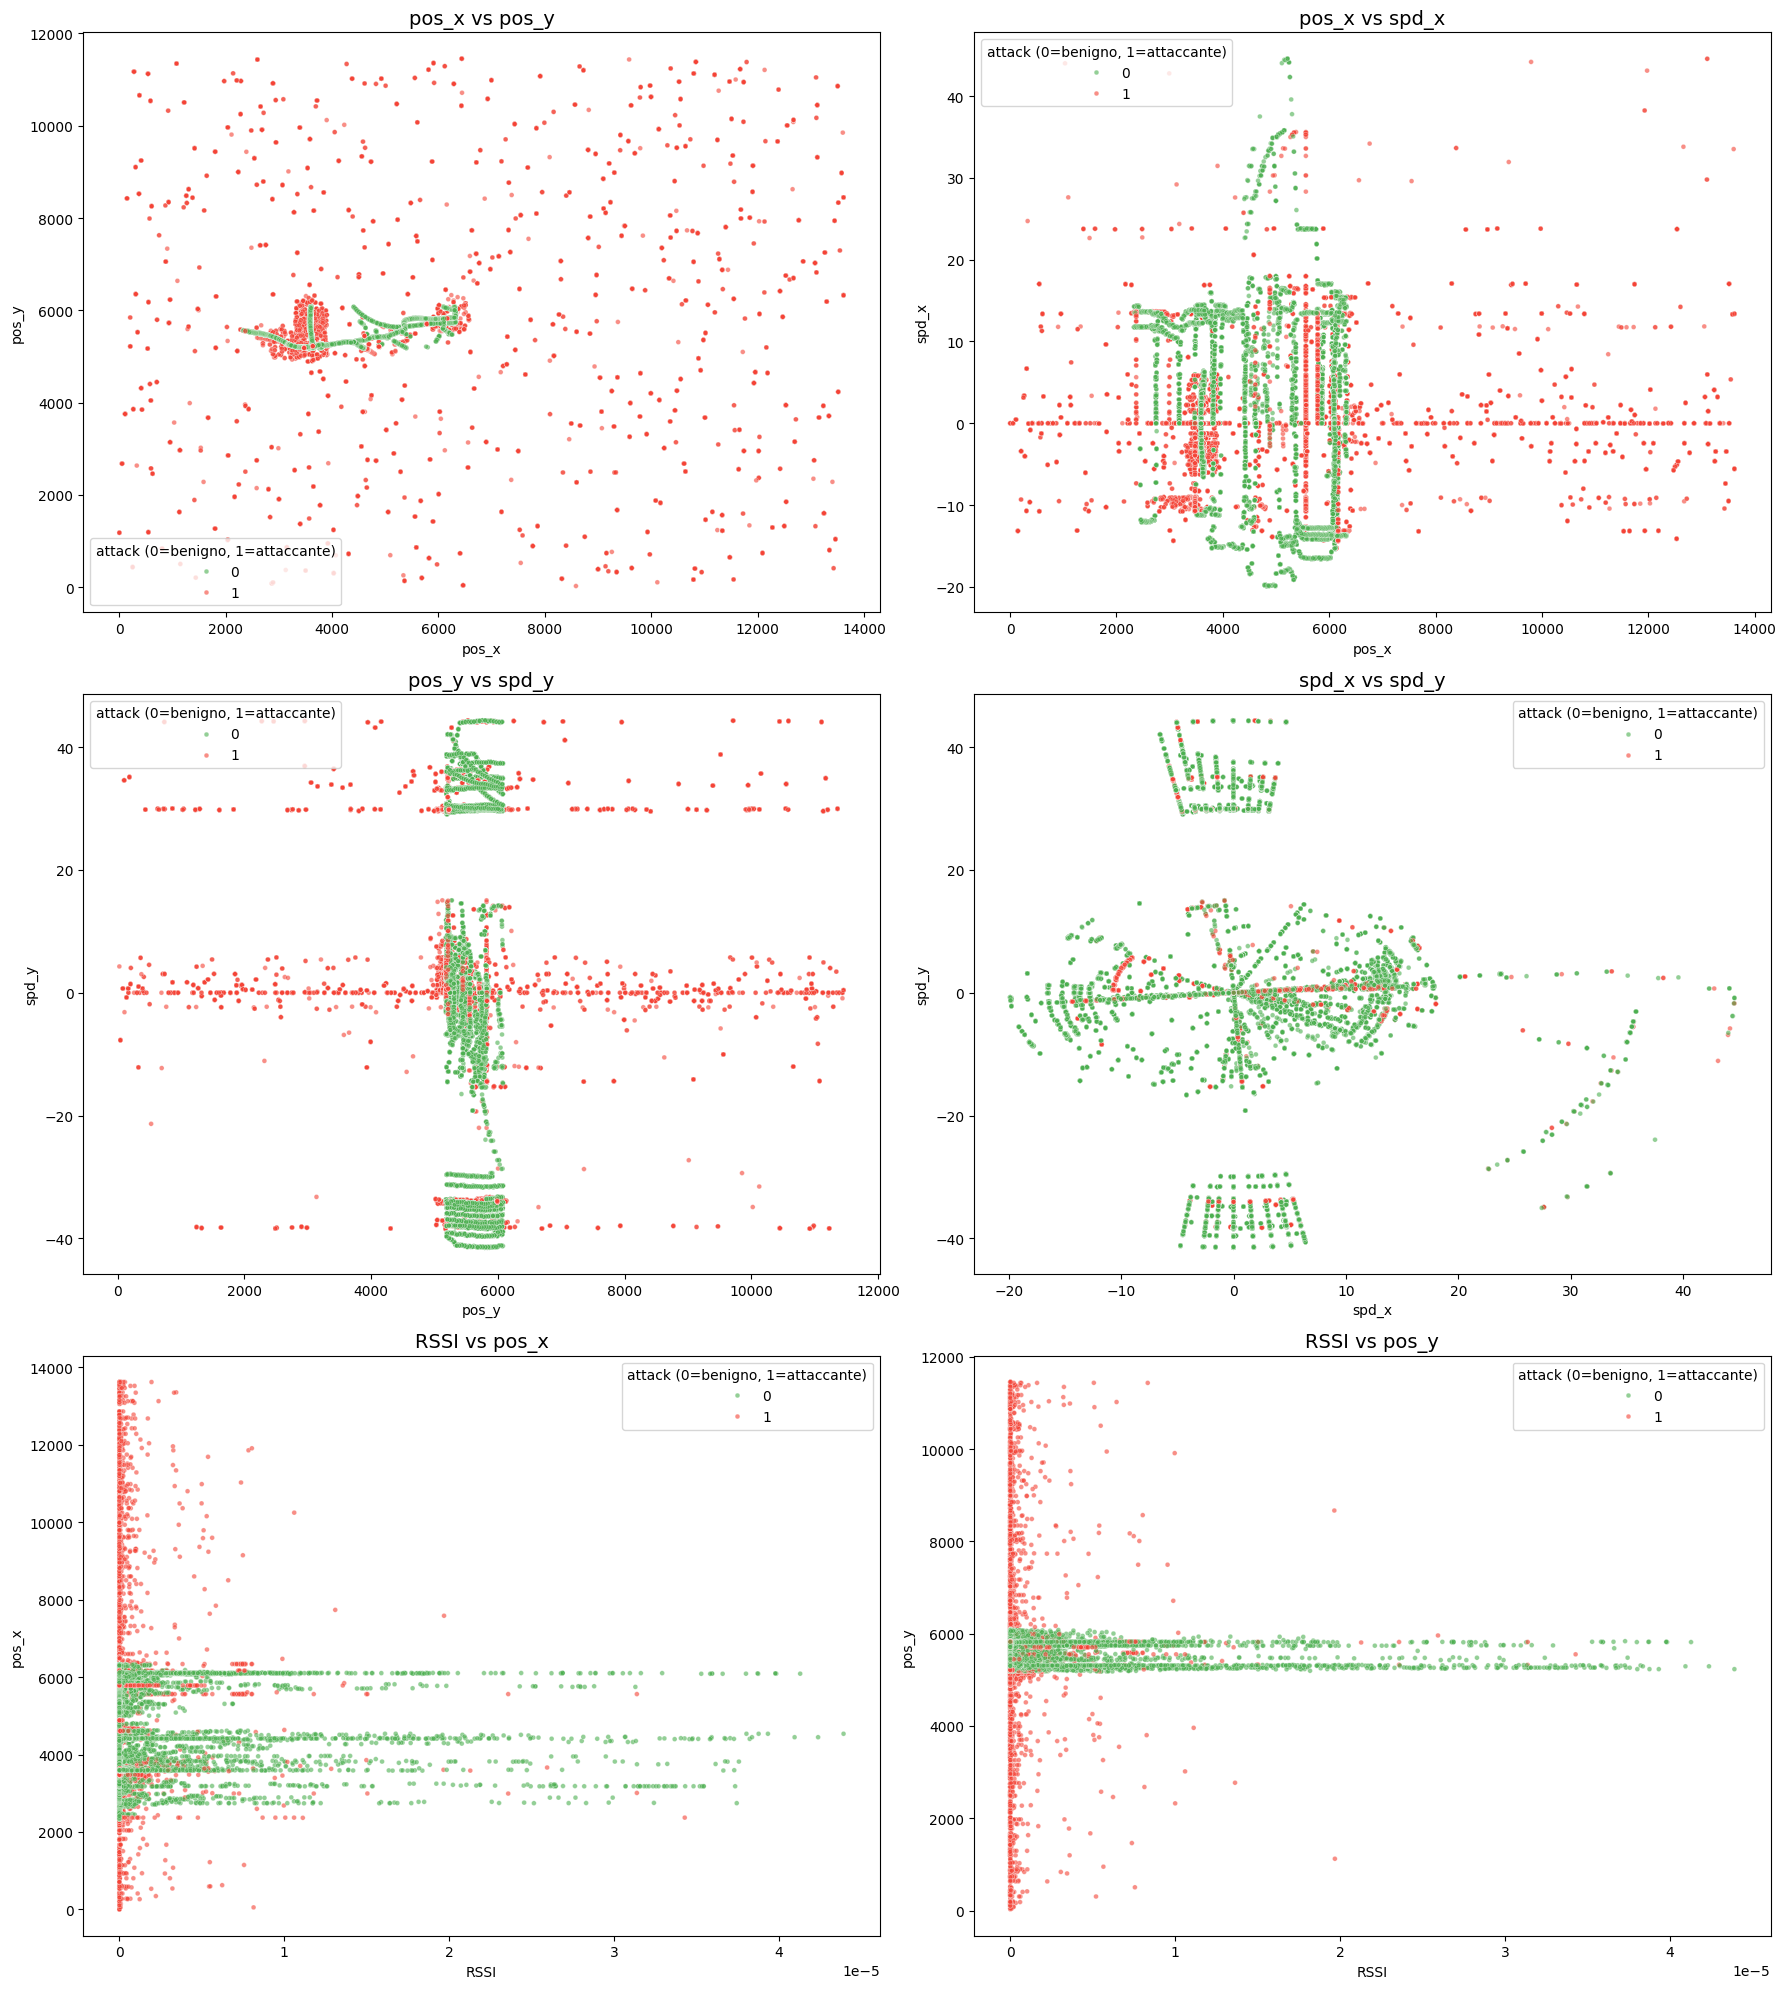

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Palette: verde (benigno), rosso (attaccante)
palette = {0: "#4CAF50", 1: "#F44336"}

fig, axs = plt.subplots(3, 2, figsize=(18, 20))
axs = axs.flatten()

plots = [
    ("pos_x", "pos_y", "pos_x vs pos_y"),
    ("pos_x", "spd_x", "pos_x vs spd_x"),
    ("pos_y", "spd_y", "pos_y vs spd_y"),
    ("spd_x", "spd_y", "spd_x vs spd_y"),
    ("RSSI", "pos_x", "RSSI vs pos_x"),
    ("RSSI", "pos_y", "RSSI vs pos_y")
]

for ax, (x, y, title) in zip(axs, plots):
    sns.scatterplot(
        data=df_clean,
        x=x,
        y=y,
        hue="attack",
        palette=palette,
        s=12,
        alpha=0.6,
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title="attack (0=benigno, 1=attaccante)")

plt.tight_layout()
plt.show()


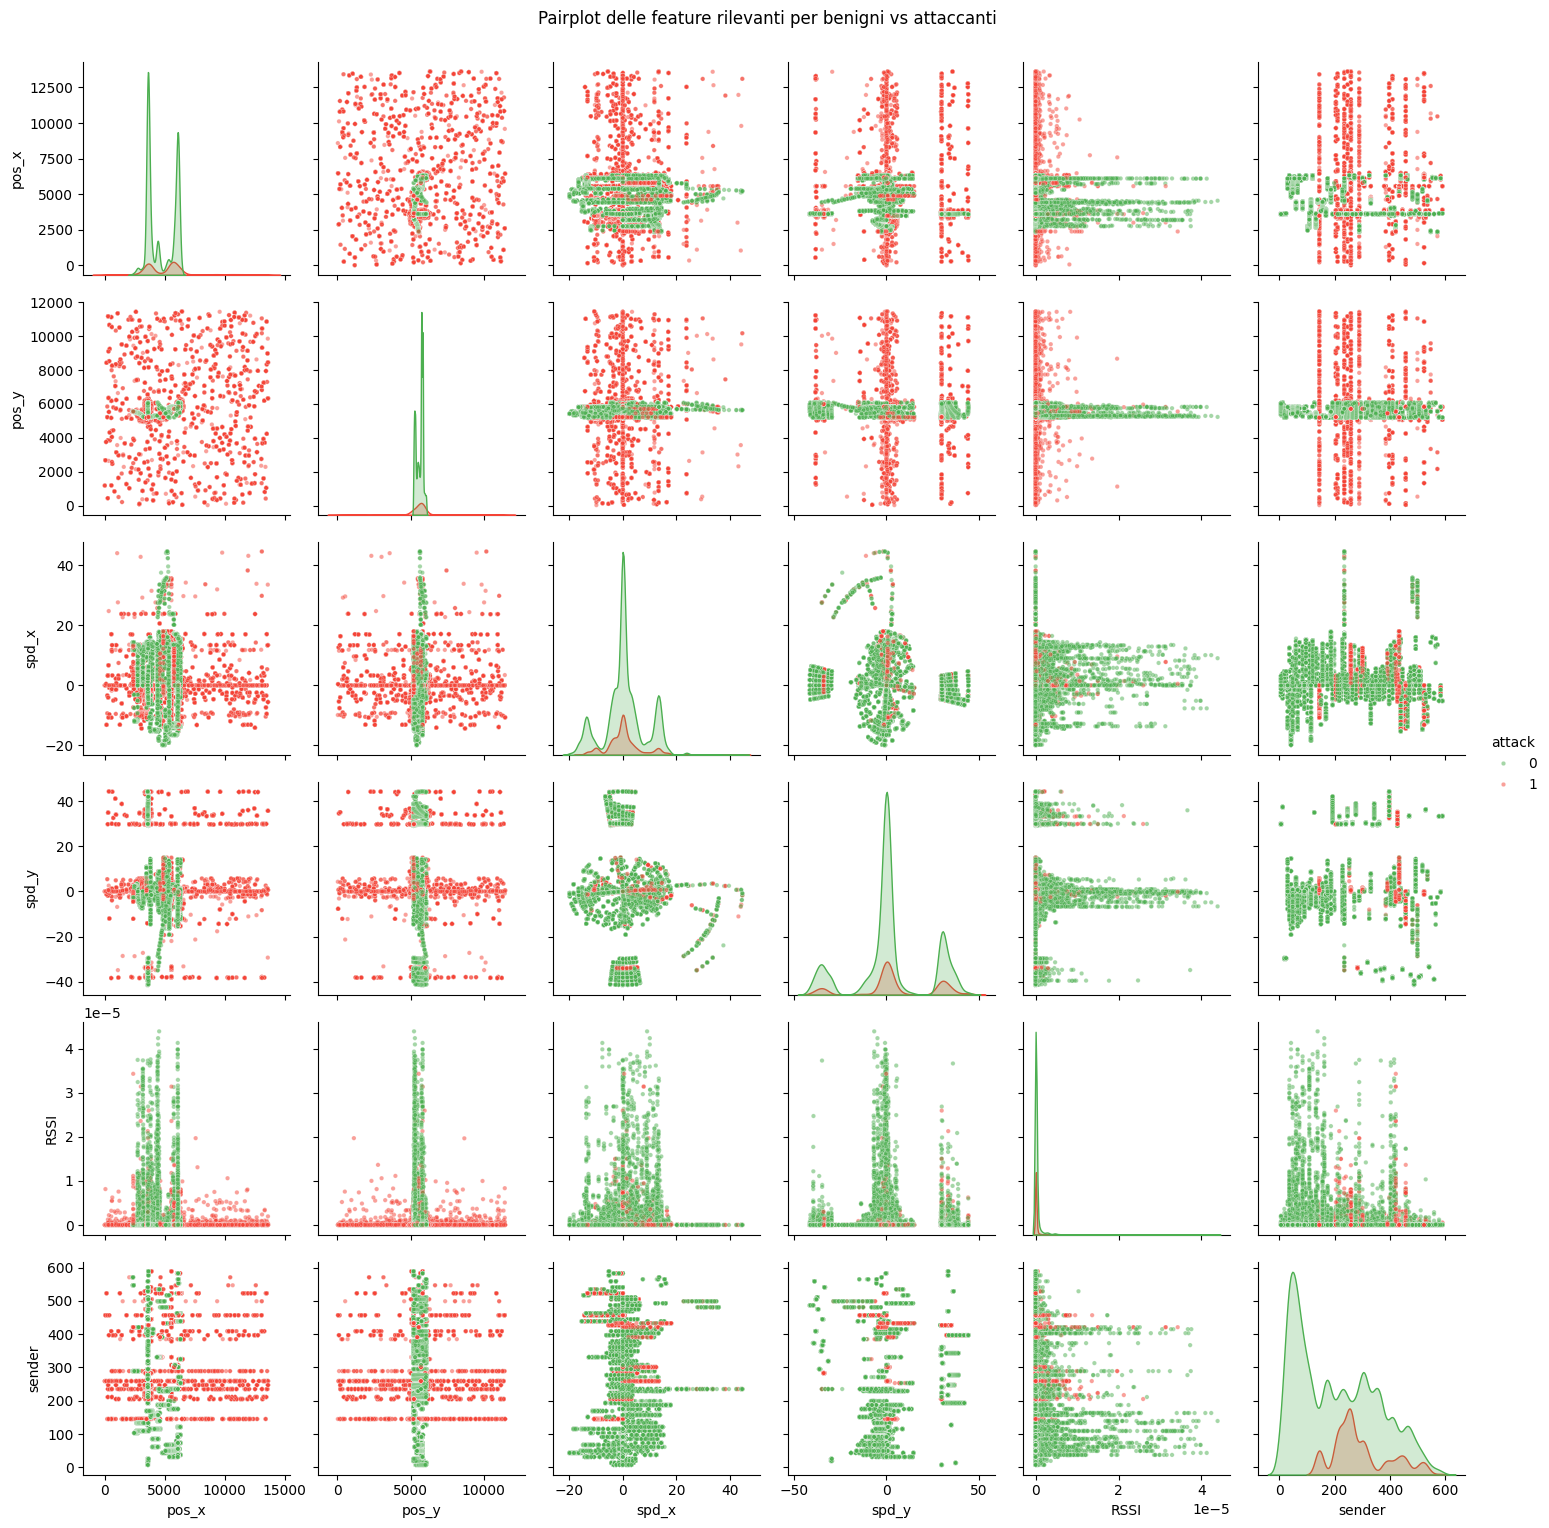

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pairplot_features = ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'RSSI', 'sender', 'attack']

sns.pairplot(
    df_clean[pairplot_features],
    hue="attack",
    diag_kind="kde",        # distribuzioni smussate sul diagonale
    plot_kws={"s": 10, "alpha": 0.5},
    palette={0: "#4CAF50", 1: "#F44336"}
)

plt.suptitle("Pairplot delle feature rilevanti per benigni vs attaccanti", y=1.02)
plt.show()


In [ ]:
# Seleziono solo le colonne numeriche
df_num = df.select_dtypes(include=['float64', 'int64'])

# Variabile target
y = df_num["attack"]

# Feature (escludo attack)
X = df_num.drop(columns=["attack"])



In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Definizione X e y
df_num = df_clean.select_dtypes(include=['float64', 'int64'])
y = df_num["attack"]
X = df_num.drop(columns=["attack"])

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

# Importanza delle feature
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nImportanza Random Forest:")
print(importances)



Importanza Random Forest:
pos_x          0.342938
pos_y          0.308266
sender         0.142931
spd_y          0.070207
spd_x          0.050643
messageID      0.028560
rcvTime        0.025358
sendTime       0.024864
RSSI           0.006232
type           0.000000
pos_noise_x    0.000000
pos_z          0.000000
pos_noise_z    0.000000
pos_noise_y    0.000000
spd_z          0.000000
spd_noise_x    0.000000
spd_noise_y    0.000000
spd_noise_z    0.000000
dtype: float64


/tmp/ipython-input-1241469644.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


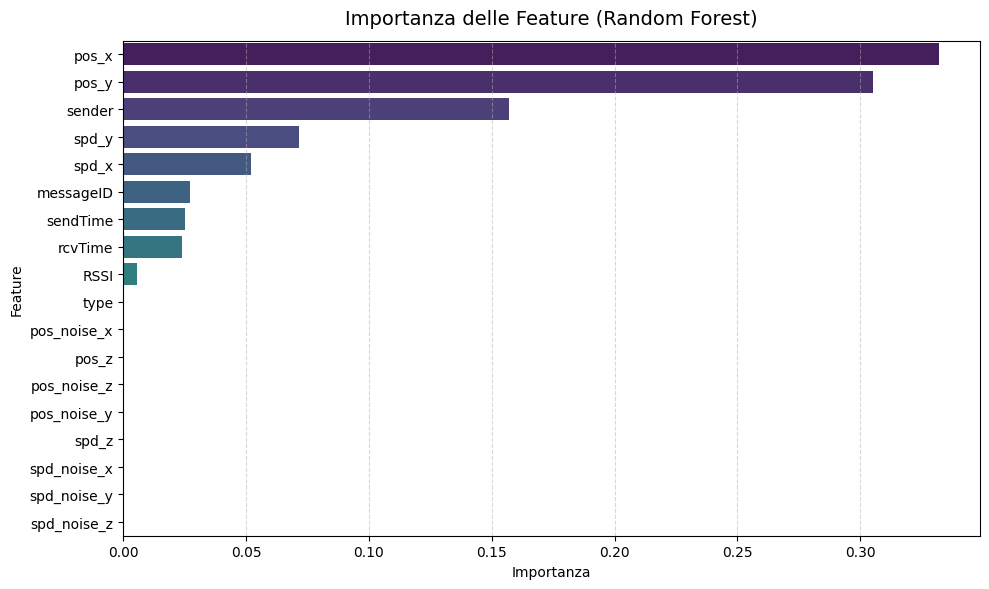

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Importances già calcolate (se non le hai, le ricalcoliamo)
from sklearn.ensemble import RandomForestClassifier

df_num = df_clean.select_dtypes(include=['float64', 'int64'])
y = df_num["attack"]
X = df_num.drop(columns=["attack"])

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# --- GRAFICO ---
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")

plt.title("Importanza delle Feature (Random Forest)", fontsize=14, pad=12)
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [67]:
import pandas as pd

top_features = ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'sender', 'messageID','sendTime']

X = df_clean[top_features]
y = df_clean['attack']


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    # SVM, KNN e LR richiedono scaling
    if name in ["Logistic Regression", "KNN", "SVM (RBF)"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

df_results = pd.DataFrame(results, columns=["Modello", "Accuracy", "Precisione", "Recall", "F1-score"])
print(df_results)


               Modello  Accuracy  Precisione    Recall  F1-score
0  Logistic Regression  0.838465    0.637201  0.123881  0.207434
1                  KNN  0.996884    0.996020  0.985678  0.990822
2            SVM (RBF)  0.901637    0.956757  0.443609  0.606164
3        Random Forest  0.999817    0.999642  0.999284  0.999463
4        Decision Tree  0.999511    0.998568  0.998568  0.998568
5          Naive Bayes  0.866325    1.000000  0.216613  0.356092


In [71]:
# Copia la tabella e arrotonda i valori
df_results_nice = df_results.copy()
df_results_nice[["Accuracy", "Precisione", "Recall", "F1-score"]] = \
    df_results_nice[["Accuracy", "Precisione", "Recall", "F1-score"]].round(4)

# Tabella con stile (sfondo header blu, testo bianco)
df_results_nice.style.set_properties(**{
    "background-color": "white",
    "color": "black",
    "border-color": "black",
    "border-width": "1px",
    "border-style": "solid",
    "text-align": "center"
}).set_table_styles([
    {"selector": "th", "props": [
        ("background-color", "#1F4E79"),
        ("color", "white"),
        ("font-weight", "bold"),
        ("text-align", "center")
    ]},
    {"selector": "td", "props": [
        ("padding", "8px")
    ]}
])


,Modello,Accuracy,Precisione,Recall,F1-score
0,Logistic Regression,0.838500,0.637200,0.123900,0.207400
1,KNN,0.996900,0.996000,0.985700,0.990800
2,SVM (RBF),0.901600,0.956800,0.443600,0.606200
3,Random Forest,0.999800,0.999600,0.999300,0.999500
4,Decision Tree,0.999500,0.998600,0.998600,0.998600
5,Naive Bayes,0.866300,1.000000,0.216600,0.356100


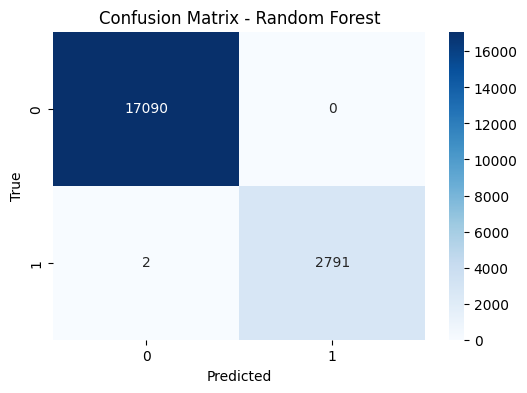

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
import pandas as pd

top_features = ['pos_x', 'pos_y', 'spd_x', 'spd_y', 'sender', 'messageID','sendTime']

X = df[top_features]
y = df['attack']